### Import Data & Libs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score, adjusted_rand_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

df_items = pd.read_excel('DATA/Order Item.xlsx',1)
df_orders = pd.read_excel('DATA/Order.xlsx',1)
df_reviews = pd.read_excel('DATA/Order Review.xlsx ',1)

df_items.columns = df_items.columns.str.strip()
df_orders.columns = df_orders.columns.str.strip()
df_reviews.columns = df_reviews.columns.str.strip()


### Feature Engineering

In [7]:
# Ép kiểu dữ liệu thời gian
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_buyer_date'] = pd.to_datetime(df_orders['order_delivered_buyer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

# Tính số ngày giao hàng và tỷ lệ đúng hạn
df_orders['delivery_days'] = (df_orders['order_delivered_buyer_date'] - df_orders['order_purchase_timestamp']).dt.days
df_orders['on_time'] = (df_orders['order_delivered_buyer_date'] <= df_orders['order_estimated_delivery_date']).astype(int)

# Gộp dữ liệu đánh giá (review)
order_reviews_agg = df_reviews.groupby('order_id')['review_score'].mean().reset_index()

# Gộp các bảng lại với nhau
df_merged = df_items.merge(df_orders[['order_id', 'delivery_days', 'on_time']], on='order_id', how='left')
df_merged = df_merged.merge(order_reviews_agg, on='order_id', how='left')

# Tính toán 13 metrics cho từng Seller
seller_features = df_merged.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'), 
    review_count=('review_score', 'count'),
    total_revenue=('sale_value', 'sum'), 
    avg_order_value=('sale_value', 'mean'), 
    std_order_value=('sale_value', 'std'),
    total_freight=('freight_value', 'sum'), 
    avg_freight=('freight_value', 'mean'),
    avg_review_score=('review_score', 'mean'), 
    std_review_score=('review_score', 'std'),
    avg_delivery_days=('delivery_days', 'mean'), 
    std_delivery_days=('delivery_days', 'std'), 
    on_time_pct=('on_time', 'mean')
).reset_index()

# Tỷ lệ phí vận chuyển trên doanh thu
seller_features['freight_to_revenue_ratio'] = seller_features['total_freight'] / seller_features['total_revenue']

# Xử lý giá trị thiếu (NaN)
seller_features = seller_features.fillna(0)

features = ['total_orders', 'review_count', 'total_revenue', 'avg_order_value', 'std_order_value',
            'total_freight', 'avg_freight', 'freight_to_revenue_ratio', 'avg_review_score', 
            'std_review_score', 'avg_delivery_days', 'std_delivery_days', 'on_time_pct']

print("Số lượng Seller:", seller_features.shape[0])

Số lượng Seller: 3095


In [8]:
seller_features.head()

,seller_id,total_orders,review_count,total_revenue,avg_order_value,std_order_value,total_freight,avg_freight,avg_review_score,std_review_score,avg_delivery_days,std_delivery_days,on_time_pct,freight_to_revenue_ratio
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,895.000000,0.000000,63.06,21.020000,3.666667,2.309401,10.333333,1.527525,1.000000,0.023486
1,001cca7ae9ae17fb1caed9dfb1094831,200,236,25080.03,104.937364,16.153486,8854.14,37.046611,3.902542,1.442159,12.653846,8.333438,0.924686,0.353035
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,250.000000,0.000000,17.94,17.940000,1.000000,0.000000,0.000000,0.000000,0.000000,0.071760
3,002100f778ceb8431b7a1020ff7ab48f,51,55,1234.50,22.445455,18.960796,793.66,14.430182,3.981818,1.407531,15.777778,8.386122,0.818182,0.642900
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000,0.000000,19.38,19.380000,5.000000,0.000000,4.000000,0.000000,1.000000,0.161500


### PCA

In [9]:
X = seller_features[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

def get_stability(model_func, data, n_iterations=10, sample_ratio=0.8):
    ari_scores = []
    base_labels = model_func(data)
    for _ in range(n_iterations):
        idx = np.random.choice(range(len(data)), size=int(len(data)*sample_ratio), replace=False)
        sample_labels = model_func(data[idx])
        ari = adjusted_rand_score(base_labels[idx], sample_labels)
        ari_scores.append(ari)
    return np.mean(ari_scores)

def get_business_variance(labels, df, metric='total_revenue'):
    valid_idx = labels != -1 
    if sum(valid_idx) == 0 or len(set(labels[valid_idx])) <= 1: return 0
    cluster_means = df.iloc[valid_idx].groupby(labels[valid_idx])[metric].mean()
    return np.std(cluster_means) / np.mean(cluster_means)

def get_dbcv_score(X_data, labels):
    try:
        from hdbscan.validity import validity_index
        if len(set(labels)) > 1: # Cần ít nhất 2 cụm để tính DBCV
            return validity_index(X_data.astype(np.float64), labels)
        return np.nan
    except ImportError:
        print("[CẢNH BÁO]: Chưa cài đặt thư viện hdbscan. Hãy chạy 'pip install hdbscan'.")
        return np.nan
    except Exception:
        return np.nan

def plot_cluster_2d(labels, title, ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(8, 6))
    is_noise = labels == -1
    if is_noise.any():
        ax.scatter(X_pca_2d[is_noise, 0], X_pca_2d[is_noise, 1], c='grey', alpha=0.3, s=20, label='Nhiễu (-1)', marker='x')
        
    clusters = [c for c in np.unique(labels) if c != -1]
    palette = sns.color_palette("Set2", len(clusters)) if len(clusters) <= 8 else sns.color_palette("husl", len(clusters))
    
    for i, cluster in enumerate(clusters):
        idx = labels == cluster
        ax.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1], color=palette[i], label=f'Cụm {cluster}', alpha=0.8, edgecolors='w', s=50)
        
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1 (Volume & Revenue)')
    ax.set_ylabel('PC2 (Quality & Operations)')
    if len(clusters) <= 10: ax.legend(loc='best', fontsize=8)
    if ax is None: plt.show()

results_dict = {}

### K-Means


--- CHỈ SỐ ĐÁNH GIÁ K-MEANS ---
- Davies-Bouldin (↓ Tốt): 1.2320
- Calinski-Harabasz (↑ Tốt): 687.4513
- DBCV (↑ Tốt): -0.7896
- Stability ARI (↑ Tốt): 0.9803
- Business Variance (↑ Tốt): 1.7230

-> ĐANG VẼ BIỂU ĐỒ PHÂN CỤM K-MEANS...


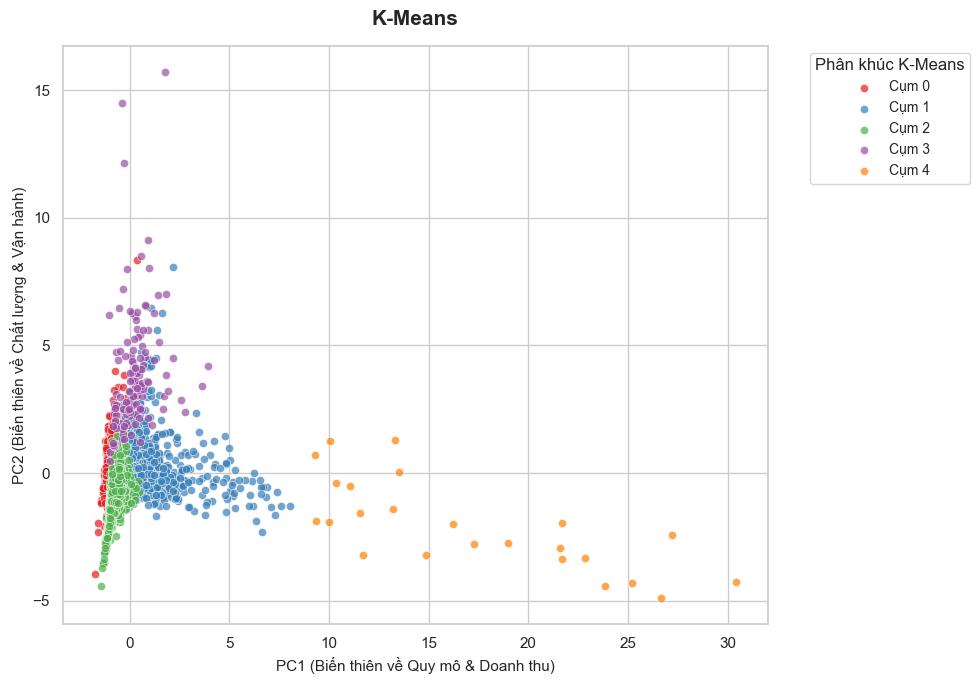

In [10]:
#K-means 5 cụm
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans_model.fit_predict(X_pca)
seller_features['KMeans_Cluster'] = labels_kmeans

#Metrics đánh giá K-means
db_score_km = davies_bouldin_score(X_pca, labels_kmeans)
ch_score_km = calinski_harabasz_score(X_pca, labels_kmeans)
dbcv_km = get_dbcv_score(X_pca, labels_kmeans) # Bổ sung DBCV
stab_score_km = get_stability(lambda d: KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(d), X_pca)
biz_var_km = get_business_variance(labels_kmeans, seller_features)

results_dict['KMeans'] = [db_score_km, ch_score_km, dbcv_km, stab_score_km, biz_var_km]

#Print
print("\n--- CHỈ SỐ ĐÁNH GIÁ K-MEANS ---")
print(f"- Davies-Bouldin (↓ Tốt): {db_score_km:.4f}")
print(f"- Calinski-Harabasz (↑ Tốt): {ch_score_km:.4f}")
print(f"- DBCV (↑ Tốt): {dbcv_km:.4f}")
print(f"- Stability ARI (↑ Tốt): {stab_score_km:.4f}")
print(f"- Business Variance (↑ Tốt): {biz_var_km:.4f}")

#Plot
print("\n-> ĐANG VẼ BIỂU ĐỒ PHÂN CỤM K-MEANS...")
plt.figure(figsize=(10, 7))

core_clusters_km = sorted(seller_features['KMeans_Cluster'].unique())
palette_km = sns.color_palette("Set1", len(core_clusters_km))

for i, cluster_id in enumerate(core_clusters_km):
    idx = seller_features['KMeans_Cluster'] == cluster_id
    plt.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1], 
                color=palette_km[i], label=f'Cụm {cluster_id}', 
                alpha=0.7, edgecolors='white', linewidth=0.5, s=35)

plt.title('K-Means', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('PC1 (Biến thiên về Quy mô & Doanh thu)', fontsize=11)
plt.ylabel('PC2 (Biến thiên về Chất lượng & Vận hành)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title="Phân khúc K-Means", title_fontsize=12)
plt.tight_layout()
plt.show()

### HDBSCAN


--- CHỈ SỐ ĐÁNH GIÁ HDBSCAN ---
- Davies-Bouldin (↓ Tốt): 0.6323
- Calinski-Harabasz (↑ Tốt): 336.0084
- DBCV (↑ Tốt): -0.3153
- Stability ARI (↑ Tốt): 0.9433
- Business Variance (↑ Tốt): 1.1973


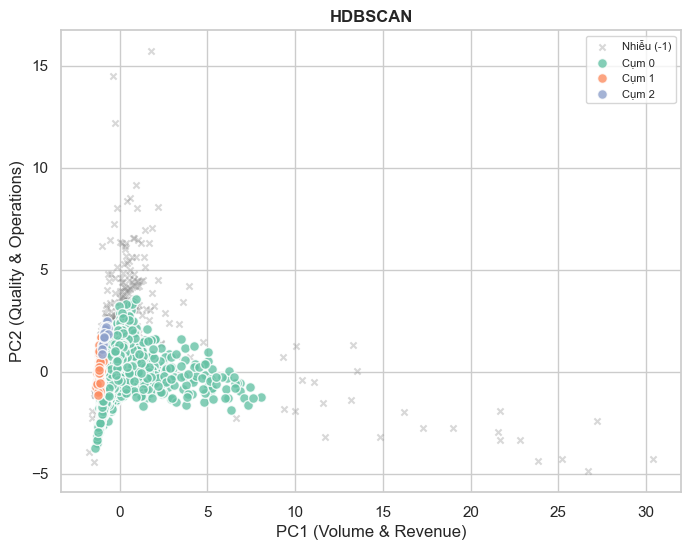

In [12]:
hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5)
labels_hdbscan = hdbscan_model.fit_predict(X_pca)
seller_features['HDBSCAN_Cluster'] = labels_hdbscan

valid_idx = labels_hdbscan != -1
if len(set(labels_hdbscan[valid_idx])) > 1:
    db_score = davies_bouldin_score(X_pca[valid_idx], labels_hdbscan[valid_idx])
    ch_score = calinski_harabasz_score(X_pca[valid_idx], labels_hdbscan[valid_idx])
else:
    db_score, ch_score = np.nan, np.nan

dbcv_score = get_dbcv_score(X_pca, labels_hdbscan) # Bổ sung DBCV (Bao gồm cả cụm nhiễu -1)
stab_score = get_stability(lambda d: HDBSCAN(min_cluster_size=15).fit_predict(d), X_pca)
biz_var = get_business_variance(labels_hdbscan, seller_features)

results_dict['HDBSCAN'] = [db_score, ch_score, dbcv_score, stab_score, biz_var]

print("\n--- CHỈ SỐ ĐÁNH GIÁ HDBSCAN ---")
print(f"- Davies-Bouldin (↓ Tốt): {db_score:.4f}")
print(f"- Calinski-Harabasz (↑ Tốt): {ch_score:.4f}")
print(f"- DBCV (↑ Tốt): {dbcv_score:.4f}")
print(f"- Stability ARI (↑ Tốt): {stab_score:.4f}")
print(f"- Business Variance (↑ Tốt): {biz_var:.4f}")

plot_cluster_2d(labels_hdbscan, 'HDBSCAN')

### GMM


--- CHỈ SỐ ĐÁNH GIÁ GMM ---
- Davies-Bouldin (↓ Tốt): 2.3273
- Calinski-Harabasz (↑ Tốt): 239.8270
- DBCV (↑ Tốt): -0.8044
- Stability ARI (↑ Tốt): 0.4958
- Business Variance (↑ Tốt): 1.3652


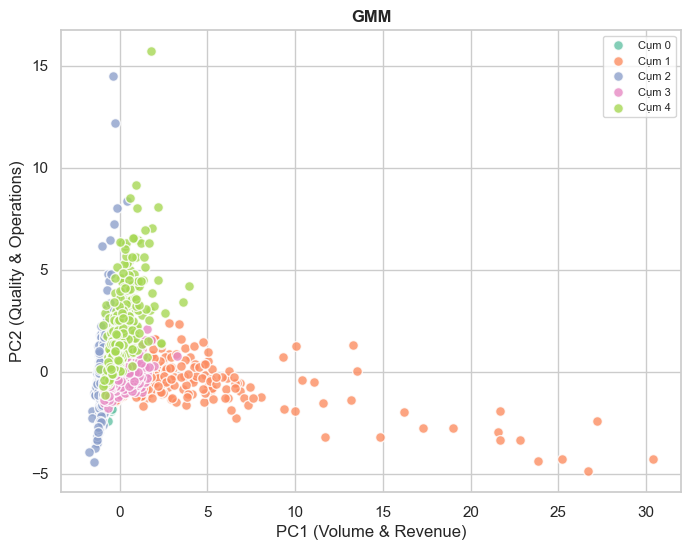

In [13]:
gmm_model = GaussianMixture(n_components=5, random_state=42)
labels_gmm = gmm_model.fit_predict(X_pca)
seller_features['GMM_Cluster'] = labels_gmm

db_score = davies_bouldin_score(X_pca, labels_gmm)
ch_score = calinski_harabasz_score(X_pca, labels_gmm)
dbcv_score = get_dbcv_score(X_pca, labels_gmm) # Bổ sung DBCV
stab_score = get_stability(lambda d: GaussianMixture(n_components=5, random_state=42).fit_predict(d), X_pca)
biz_var = get_business_variance(labels_gmm, seller_features)

results_dict['GMM'] = [db_score, ch_score, dbcv_score, stab_score, biz_var]

print("\n--- CHỈ SỐ ĐÁNH GIÁ GMM ---")
print(f"- Davies-Bouldin (↓ Tốt): {db_score:.4f}")
print(f"- Calinski-Harabasz (↑ Tốt): {ch_score:.4f}")
print(f"- DBCV (↑ Tốt): {dbcv_score:.4f}")
print(f"- Stability ARI (↑ Tốt): {stab_score:.4f}")
print(f"- Business Variance (↑ Tốt): {biz_var:.4f}")

plot_cluster_2d(labels_gmm, 'GMM')

### Autoencoder + HDBSCAN


--- CHỈ SỐ ĐÁNH GIÁ DEEP CLUSTERING ---
- Davies-Bouldin (↓ Tốt): 0.3882
- Calinski-Harabasz (↑ Tốt): 1260.0032
- DBCV (↑ Tốt): -0.1756
- Stability ARI (↑ Tốt): 0.4525
- Business Variance (↑ Tốt): 0.8670


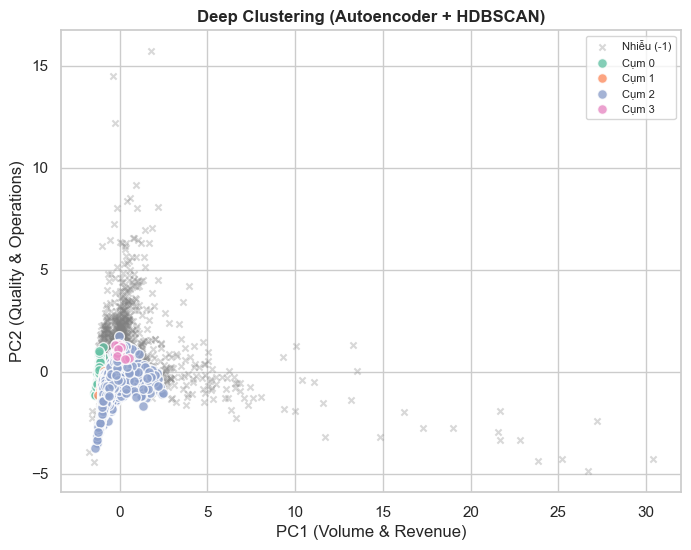

In [14]:
input_dim = X_scaled.shape[1]
encoding_dim = 3

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(8, activation='relu')(input_layer)
bottleneck = Dense(encoding_dim, activation='relu')(encoder_layer)
decoder_layer = Dense(8, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='linear')(decoder_layer)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
encoder = Model(inputs=input_layer, outputs=bottleneck)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, shuffle=True, verbose=0)
X_latent = encoder.predict(X_scaled, verbose=0)

labels_deep = HDBSCAN(min_cluster_size=15).fit_predict(X_latent)
seller_features['Deep_HDBSCAN_Cluster'] = labels_deep

valid_idx = labels_deep != -1
if len(set(labels_deep[valid_idx])) > 1:
    db_score = davies_bouldin_score(X_latent[valid_idx], labels_deep[valid_idx])
    ch_score = calinski_harabasz_score(X_latent[valid_idx], labels_deep[valid_idx])
else:
    db_score, ch_score = np.nan, np.nan

dbcv_score = get_dbcv_score(X_latent, labels_deep) 
stab_score = get_stability(lambda d: HDBSCAN(min_cluster_size=15).fit_predict(encoder.predict(d, verbose=0)), X_scaled)
biz_var = get_business_variance(labels_deep, seller_features)

results_dict['Deep Clustering'] = [db_score, ch_score, dbcv_score, stab_score, biz_var]

print("\n--- CHỈ SỐ ĐÁNH GIÁ DEEP CLUSTERING ---")
print(f"- Davies-Bouldin (↓ Tốt): {db_score:.4f}")
print(f"- Calinski-Harabasz (↑ Tốt): {ch_score:.4f}")
print(f"- DBCV (↑ Tốt): {dbcv_score:.4f}")
print(f"- Stability ARI (↑ Tốt): {stab_score:.4f}")
print(f"- Business Variance (↑ Tốt): {biz_var:.4f}")

# Plot từ Latent Space chiếu lên PCA 2D để cùng góc nhìn với các phương pháp khác
plot_cluster_2d(labels_deep, 'Deep Clustering (Autoencoder + HDBSCAN)')

### Tổng hợp & So sánh

=== BẢNG ĐÁNH GIÁ CHỈ SỐ CÁC MÔ HÌNH ===


,Davies-Bouldin (↓ Tốt),Calinski-Harabasz (↑ Tốt),DBCV (↑ Tốt),Stability ARI (↑ Tốt),Business Variance (↑ Tốt)
KMeans,1.2320,687.4513,-0.7896,0.9803,1.7230
HDBSCAN,0.6323,336.0084,-0.3153,0.9433,1.1973
GMM,2.3273,239.8270,-0.8044,0.4958,1.3652
Deep Clustering,0.3882,1260.0032,-0.1756,0.4525,0.8670


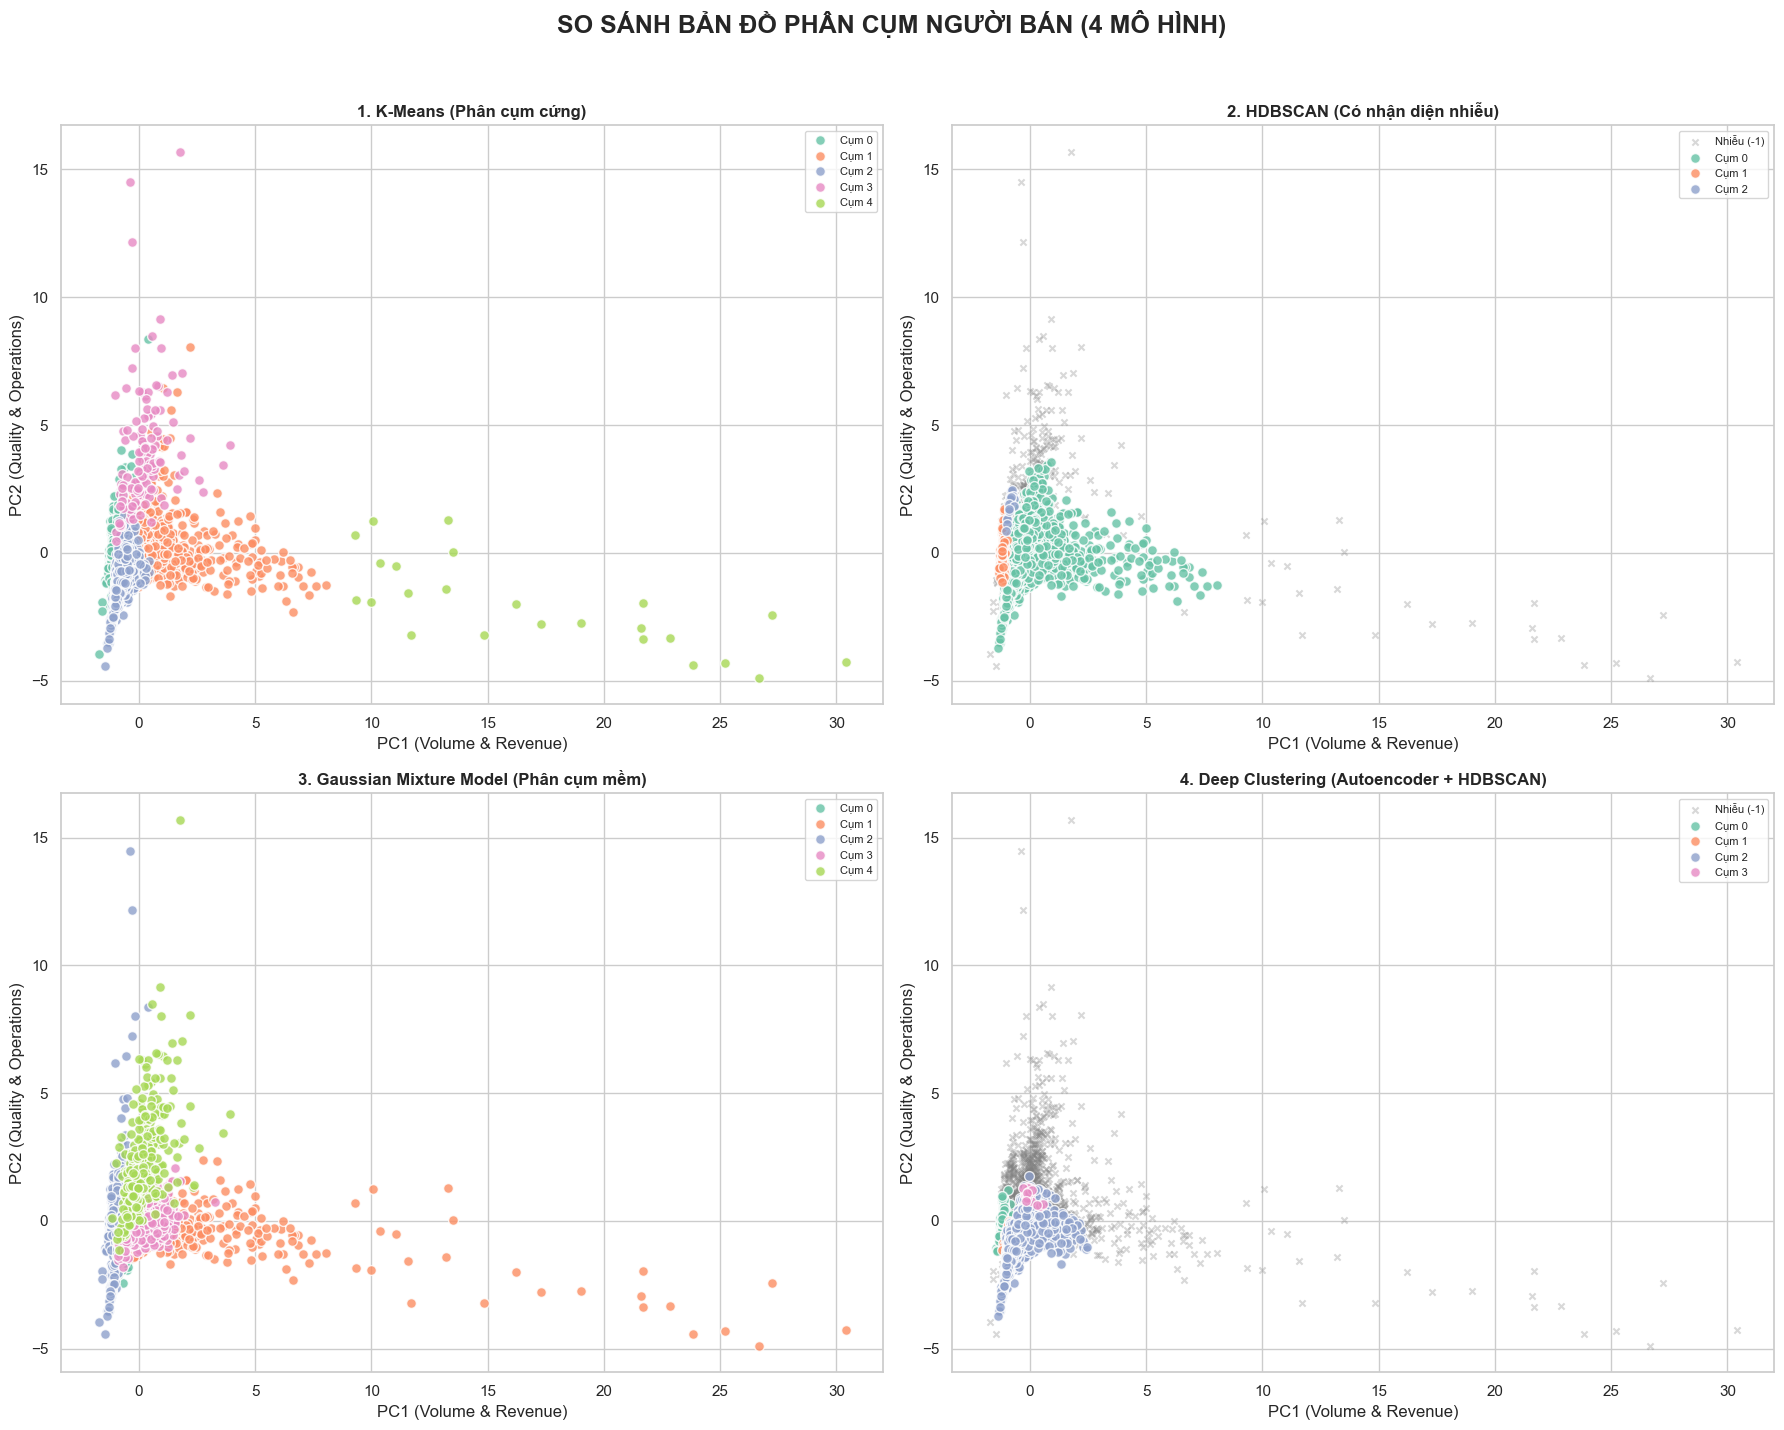

In [15]:
ordered_keys = ['KMeans', 'HDBSCAN', 'GMM', 'Deep Clustering']
results_dict_ordered = {k: results_dict[k] for k in ordered_keys if k in results_dict}

# Tạo Dataframe Bảng so sánh (Bổ sung Index DBCV)
df_results = pd.DataFrame(results_dict_ordered, index=[
    'Davies-Bouldin (↓ Tốt)', 
    'Calinski-Harabasz (↑ Tốt)', 
    'DBCV (↑ Tốt)', 
    'Stability ARI (↑ Tốt)', 
    'Business Variance (↑ Tốt)'
]).T

print("=== BẢNG ĐÁNH GIÁ CHỈ SỐ CÁC MÔ HÌNH ===")
display(df_results.round(4)) 

# Vẽ 4 biểu đồ cạnh nhau (Grid 2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SO SÁNH BẢN ĐỒ PHÂN CỤM NGƯỜI BÁN (4 MÔ HÌNH)', 
             fontsize=18, fontweight='bold', y=1.02)

plot_cluster_2d(seller_features['KMeans_Cluster'], '1. K-Means (Phân cụm cứng)', ax=axes[0, 0])
plot_cluster_2d(seller_features['HDBSCAN_Cluster'], '2. HDBSCAN (Có nhận diện nhiễu)', ax=axes[0, 1])
plot_cluster_2d(seller_features['GMM_Cluster'], '3. Gaussian Mixture Model (Phân cụm mềm)', ax=axes[1, 0])
plot_cluster_2d(seller_features['Deep_HDBSCAN_Cluster'], '4. Deep Clustering (Autoencoder + HDBSCAN)', ax=axes[1, 1])

plt.tight_layout()
plt.show()

### Seller Segmentation HDBSCAN


=== BẢNG TÓM TẮT TRỰC QUAN CÁC PHÂN KHÚC ===
              Business_Label  Percentage(%)  Volume  Revenue  Rating  On_Time_Rate  Avg_Delivery_Days                                                Key_Strength_Weakness
Ngoại lai / Siêu cá mập (-1)           8.82   94.74 16569.89    3.33          0.66              18.33 S: Quy mô mang tính đột biến / W: Hành vi dị biệt, Khó quản lý chung
             Nhóm Chiến lược          86.95   27.49  3360.74    4.15          0.91              10.78       S: Doanh thu & Review top đầu / W: (Không có điểm yếu đáng kể)
                 Nhóm Rủi ro           0.68    1.38   203.91    1.05          0.02              33.76                S: (Không có) / W: Trải nghiệm KH kém, Giao hàng chậm
    Nhóm Đại chúng (Cụm 1.0)           3.55    1.20   179.00    1.59          0.00               0.82     S: Chỉ số ổn định, an toàn / W: Thiếu động lực bứt phá doanh thu


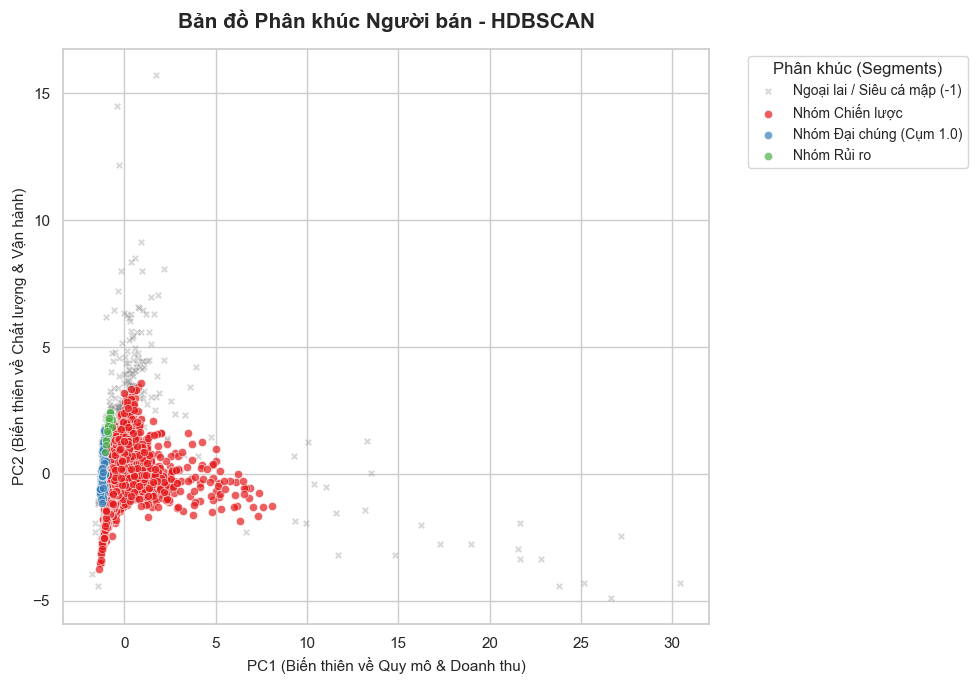

In [ ]:
hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5)
labels_hdbscan = hdbscan_model.fit_predict(X_pca)
seller_features['HDBSCAN_Cluster'] = labels_hdbscan

total_sellers = len(seller_features)
cluster_metrics = seller_features.groupby('HDBSCAN_Cluster').agg(
    Volume=('total_orders', 'mean'),
    Revenue=('total_revenue', 'mean'),
    Rating=('avg_review_score', 'mean'),
    On_Time_Rate=('on_time_pct', 'mean'),
    Avg_Delivery_Days=('avg_delivery_days', 'mean'), # Thêm cột thời gian giao hàng
    Seller_Count=('seller_id', 'count')
).reset_index()

cluster_metrics['Percentage(%)'] = (cluster_metrics['Seller_Count'] / total_sellers * 100).round(2)

def assign_business_label(row, all_metrics):
    cluster_id = row['HDBSCAN_Cluster']
    if cluster_id == -1:
        return "Outliers (-1)"
    
    valid_metrics = all_metrics[all_metrics['HDBSCAN_Cluster'] != -1]
    max_rev_cluster = valid_metrics.loc[valid_metrics['Revenue'].idxmax(), 'HDBSCAN_Cluster']
    min_rating_cluster = valid_metrics.loc[valid_metrics['Rating'].idxmin(), 'HDBSCAN_Cluster']
    max_orders_cluster = valid_metrics.loc[valid_metrics['Volume'].idxmax(), 'HDBSCAN_Cluster']
    
    if cluster_id == max_rev_cluster:
        return "Strategic"
    elif cluster_id == min_rating_cluster:
        return "Underperforming"
    #elif cluster_id == max_orders_cluster:
        #return "Nhóm Cày số lượng"
    else:
        return f"Normal (Cụm {cluster_id})"

cluster_metrics['Business_Label'] = cluster_metrics.apply(lambda row: assign_business_label(row, cluster_metrics), axis=1)
label_mapping = dict(zip(cluster_metrics['HDBSCAN_Cluster'], cluster_metrics['Business_Label']))
seller_features['HDBSCAN_Business_Label'] = seller_features['HDBSCAN_Cluster'].map(label_mapping)

def assign_strength_weakness(label):
    if "Chiến lược" in label:
        return "S: Doanh thu & Review top đầu / W: (Không có điểm yếu đáng kể)"
    elif "Rủi ro" in label:
        return "S: (Không có) / W: Trải nghiệm KH kém, Giao hàng chậm"
    elif "Cày số lượng" in label:
        return "S: Lượng đơn khủng, Thanh khoản tốt / W: AOV (Giá trị đơn) thấp"
    elif "Ngoại lai" in label:
        return "S: Quy mô mang tính đột biến / W: Hành vi dị biệt, Khó quản lý chung"
    else:
        return "S: Chỉ số ổn định, an toàn / W: Thiếu động lực bứt phá doanh thu"

cluster_metrics['Key_Strength_Weakness'] = cluster_metrics['Business_Label'].apply(assign_strength_weakness)

print("\n=== BẢNG TÓM TẮT TRỰC QUAN CÁC PHÂN KHÚC ===")
display_table = cluster_metrics[[
    'Business_Label', 'Percentage(%)', 'Volume', 'Revenue', 
    'Rating', 'On_Time_Rate', 'Avg_Delivery_Days', 'Key_Strength_Weakness'
]]
display_table = display_table.sort_values(by='Revenue', ascending=False).round(2)

import pandas as pd
pd.set_option('display.max_colwidth', None)
print(display_table.to_string(index=False))
pd.reset_option('display.max_colwidth') # Trả lại mặc định sau khi in xong

plt.figure(figsize=(10, 7))

is_outlier = seller_features['HDBSCAN_Cluster'] == -1
if is_outlier.any():
    plt.scatter(X_pca_2d[is_outlier, 0], X_pca_2d[is_outlier, 1], 
                c='grey', alpha=0.3, s=15, label=label_mapping[-1], marker='x')

core_clusters = [c for c in seller_features['HDBSCAN_Cluster'].unique() if c != -1]
palette = sns.color_palette("Set1", len(core_clusters))

for i, cluster_id in enumerate(sorted(core_clusters)):
    idx = seller_features['HDBSCAN_Cluster'] == cluster_id
    label_name = label_mapping[cluster_id]
    plt.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1], 
                color=palette[i], label=label_name, alpha=0.7, edgecolors='white', linewidth=0.5, s=35)

plt.title('Bản đồ Phân khúc Người bán - HDBSCAN', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('PC1 (Biến thiên về Quy mô & Doanh thu)', fontsize=11)
plt.ylabel('PC2 (Biến thiên về Chất lượng & Vận hành)', fontsize=11)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title="Phân khúc (Segments)", title_fontsize=12)
plt.tight_layout()
plt.show()

### Violin Distribution Plot

9. ĐANG VẼ BIỂU ĐỒ VIOLIN PLOT...


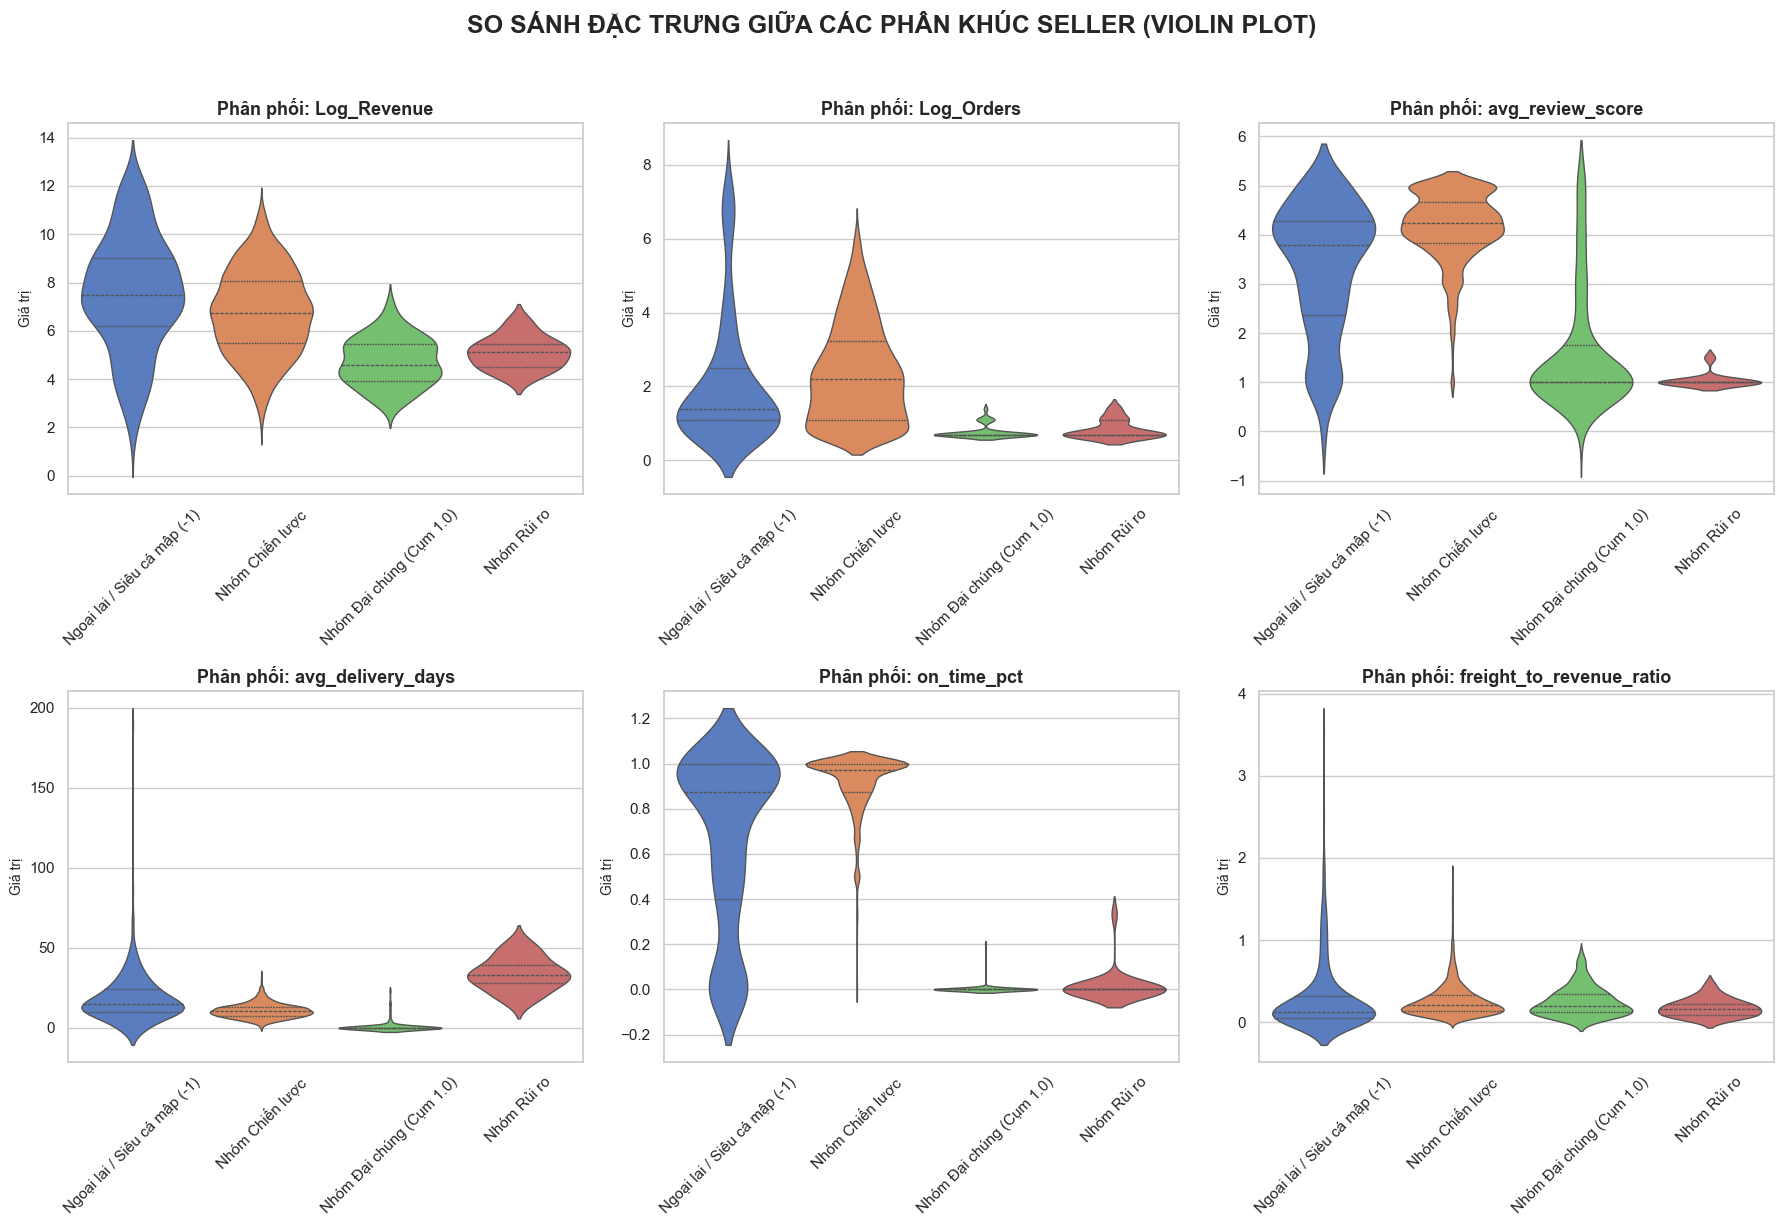

In [ ]:
cluster_col = 'HDBSCAN_Business_Label' 

features_to_plot = [
    'total_revenue', 
    'total_orders', 
    'avg_review_score', 
    'avg_delivery_days', 
    'on_time_pct', 
    'freight_to_revenue_ratio'
]


df_plot = seller_features.copy()
df_plot['Log_Revenue'] = np.log1p(df_plot['total_revenue'])
df_plot['Log_Orders'] = np.log1p(df_plot['total_orders'])

plot_features = [
    'Log_Revenue', 'Log_Orders', 'avg_review_score', 
    'avg_delivery_days', 'on_time_pct', 'freight_to_revenue_ratio'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

for i, feature in enumerate(plot_features):
    sns.violinplot(
        data=df_plot, 
        x=cluster_col, 
        y=feature, 
        ax=axes[i],
        palette='muted',
        inner='quartile', 
        scale='width',    
        linewidth=1
    )
    
    axes[i].set_title(f'Phân phối: {feature}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Giá trị', fontsize=10)
    axes[i].set_xlabel('')
    
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('SO SÁNH ĐẶC TRƯNG GIỮA CÁC PHÂN KHÚC SELLER (VIOLIN PLOT)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Barplot

=== BẢNG TỔNG HỢP CHỈ SỐ CÁC PHÂN KHÚC ===


,HDBSCAN_Business_Label,Percentage(%),Volume,Revenue,Rating,On_Time_Rate,Avg_Delivery_Days
0,Ngoại lai / Siêu cá mập (-1),8.82,94.74,16569.89,3.33,0.66,18.33
1,Nhóm Chiến lược,86.95,27.49,3360.74,4.15,0.91,10.78
2,Nhóm Rủi ro,0.68,1.38,203.91,1.05,0.02,33.76
3,Nhóm Đại chúng (Cụm 1.0),3.55,1.20,179.00,1.59,0.00,0.82


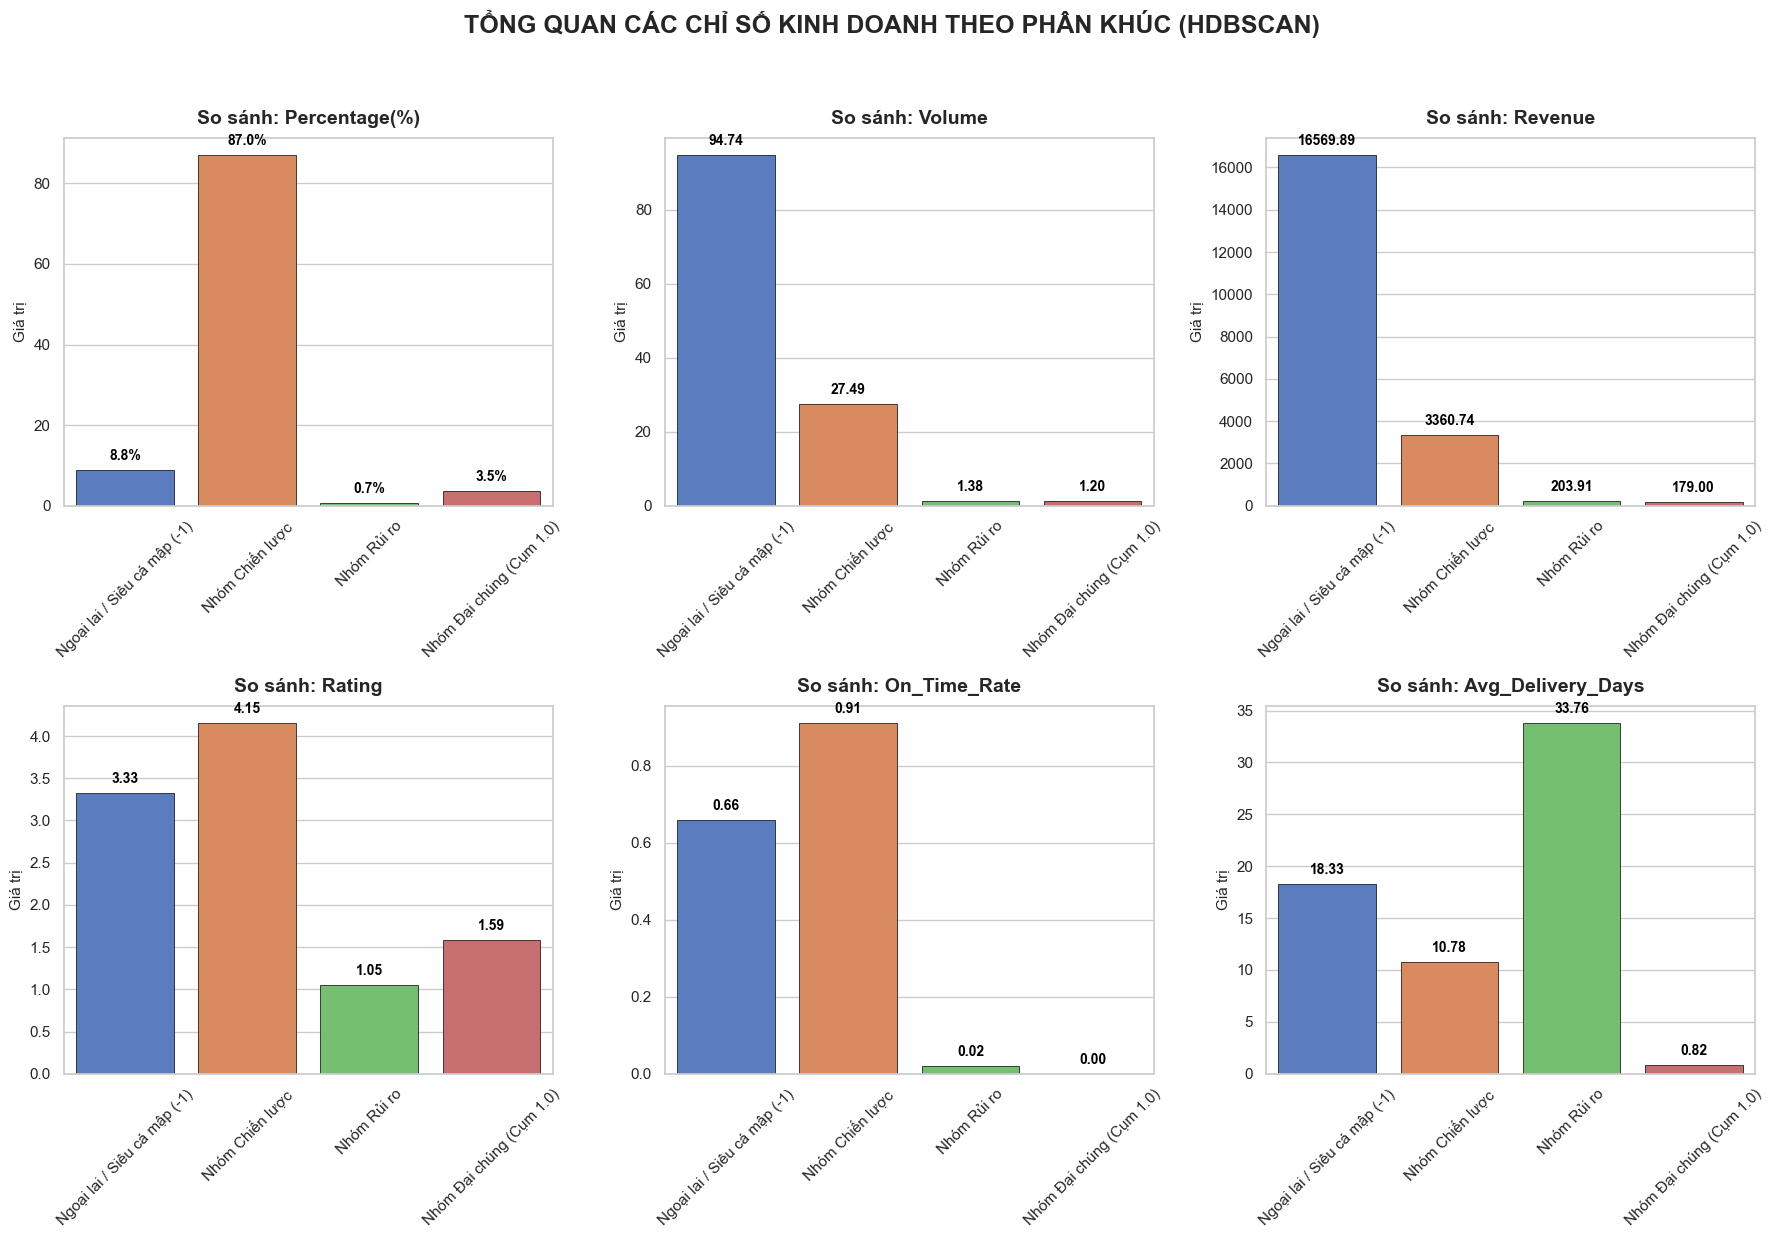

In [18]:
total_sellers = len(seller_features)

cluster_summary = seller_features.groupby('HDBSCAN_Business_Label').agg(
    Seller_Count=('seller_id', 'count'),
    Volume=('total_orders', 'mean'),
    Revenue=('total_revenue', 'mean'),
    Rating=('avg_review_score', 'mean'),
    On_Time_Rate=('on_time_pct', 'mean'),
    Avg_Delivery_Days=('avg_delivery_days', 'mean')
).reset_index()

cluster_summary['Percentage(%)'] = (cluster_summary['Seller_Count'] / total_sellers * 100)

final_columns = [
    'HDBSCAN_Business_Label', 'Percentage(%)', 'Volume', 
    'Revenue', 'Rating', 'On_Time_Rate', 'Avg_Delivery_Days'
]
cluster_summary = cluster_summary[final_columns].round(2)

print("=== BẢNG TỔNG HỢP CHỈ SỐ CÁC PHÂN KHÚC ===")
import pandas as pd
pd.set_option('display.max_colwidth', None)
display(cluster_summary) 
pd.reset_option('display.max_colwidth')


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

metrics_to_plot = ['Percentage(%)', 'Volume', 'Revenue', 'Rating', 'On_Time_Rate', 'Avg_Delivery_Days']
palette = sns.color_palette("muted", len(cluster_summary))

for i, metric in enumerate(metrics_to_plot):
    ax = sns.barplot(
        data=cluster_summary, 
        x='HDBSCAN_Business_Label', 
        y=metric, 
        ax=axes[i], 
        palette=palette,
        edgecolor='black',
        linewidth=0.5
    )
    
    axes[i].set_title(f'So sánh: {metric}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_ylabel('Giá trị', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    for p in axes[i].patches:
        height = p.get_height()
        text_format = f'{height:.2f}' if metric != 'Percentage(%)' else f'{height:.1f}%'
        axes[i].annotate(
            text_format, 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            xytext=(0, 5), textcoords='offset points', 
            fontsize=10, fontweight='bold', color='black'
        )

plt.suptitle('TỔNG QUAN CÁC CHỈ SỐ KINH DOANH THEO PHÂN KHÚC (HDBSCAN)', 
             fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### PCA Components

8. TRÍCH XUẤT TRỌNG SỐ PCA - BẰNG CHỨNG TOÁN HỌC

--- TOP BIẾN ĐẨY TRỤC PC1 SANG PHẢI (Quy mô & Doanh thu) ---
                          PC1_Weight
review_count                  0.4951
total_orders                  0.4934
total_freight                 0.4928
total_revenue                 0.4609
std_delivery_days             0.1472
std_review_score              0.1424
std_order_value               0.0719
avg_delivery_days             0.0635
on_time_pct                   0.0379
avg_order_value               0.0146
avg_review_score              0.0086
avg_freight                   0.0044
freight_to_revenue_ratio     -0.0574


--- TOP BIẾN ĐẨY TRỤC PC2 LÊN CAO (Rủi ro Vận hành) ---
                          PC2_Weight
avg_order_value               0.4600
std_order_value               0.3953
avg_freight                   0.3705
avg_delivery_days             0.3308
std_delivery_days             0.2934
std_review_score              0.2539
total_revenue                 0.0142
total_freight    

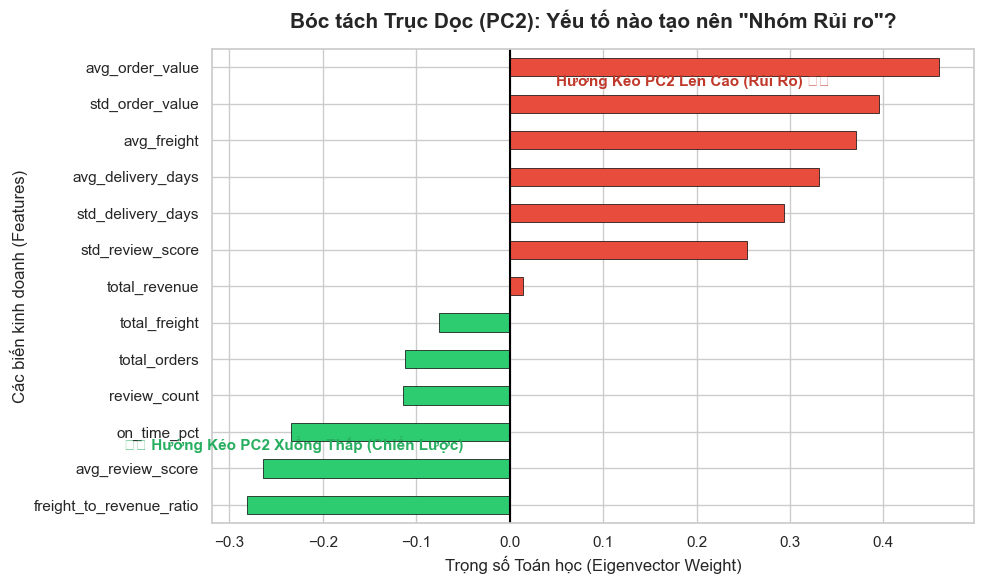

In [19]:

print("8. TRÍCH XUẤT TRỌNG SỐ PCA - BẰNG CHỨNG TOÁN HỌC\n")

pca_weights = pd.DataFrame(
    pca_2d.components_.T, 
    index=features, 
    columns=['PC1_Weight', 'PC2_Weight']
)

print("--- TOP BIẾN ĐẨY TRỤC PC1 SANG PHẢI (Quy mô & Doanh thu) ---")
pc1_sorted = pca_weights[['PC1_Weight']].sort_values(by='PC1_Weight', ascending=False)
print(pc1_sorted.round(4).to_string())
print("\n")

print("--- TOP BIẾN ĐẨY TRỤC PC2 LÊN CAO (Rủi ro Vận hành) ---")
pc2_sorted = pca_weights[['PC2_Weight']].sort_values(by='PC2_Weight', ascending=False)
print(pc2_sorted.round(4).to_string())

plt.figure(figsize=(10, 6))

pc2_plot_data = pca_weights['PC2_Weight'].sort_values()

colors = ['#e74c3c' if val > 0 else '#2ecc71' for val in pc2_plot_data]

pc2_plot_data.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Bóc tách Trục Dọc (PC2): Yếu tố nào tạo nên "Nhóm Rủi ro"?', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Trọng số Toán học (Eigenvector Weight)', fontsize=12)
plt.ylabel('Các biến kinh doanh (Features)', fontsize=12)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

plt.text(0.05, len(features)-1.5, 'Hướng Kéo PC2 Lên Cao (Rủi Ro) ⬆️', color='#c0392b', fontweight='bold', fontsize=11)
plt.text(-0.05, 1.5, '⬇️ Hướng Kéo PC2 Xuống Thấp (Chiến Lược)', color='#27ae60', fontweight='bold', fontsize=11, ha='right')

plt.tight_layout()
plt.show()

--- TOP BIẾN ĐẨY TRỤC PC1 LÊN CAO (Dịch sang phải biểu đồ) ---
                          PC1_Weight
review_count                  0.4951
total_orders                  0.4934
total_freight                 0.4928
total_revenue                 0.4609
std_delivery_days             0.1472
std_review_score              0.1424
std_order_value               0.0719
avg_delivery_days             0.0635
on_time_pct                   0.0379
avg_order_value               0.0146
avg_review_score              0.0086
avg_freight                   0.0044
freight_to_revenue_ratio     -0.0574


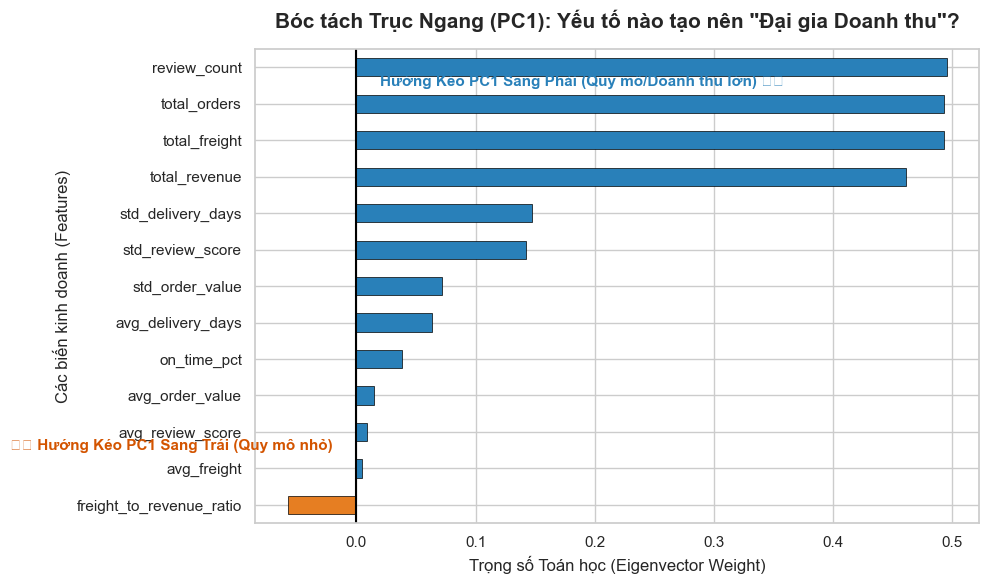

In [20]:
pca_weights = pd.DataFrame(
    pca_2d.components_.T, 
    index=features, 
    columns=['PC1_Weight', 'PC2_Weight']
)

print("--- TOP BIẾN ĐẨY TRỤC PC1 LÊN CAO (Dịch sang phải biểu đồ) ---")
pc1_sorted = pca_weights[['PC1_Weight']].sort_values(by='PC1_Weight', ascending=False)
print(pc1_sorted.round(4).to_string())

plt.figure(figsize=(10, 6))

pc1_plot_data = pca_weights['PC1_Weight'].sort_values()

colors_pc1 = ['#2980b9' if val > 0 else '#e67e22' for val in pc1_plot_data]

pc1_plot_data.plot(kind='barh', color=colors_pc1, edgecolor='black', linewidth=0.5)

plt.title('Bóc tách Trục Ngang (PC1): Yếu tố nào tạo nên "Đại gia Doanh thu"?', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Trọng số Toán học (Eigenvector Weight)', fontsize=12)
plt.ylabel('Các biến kinh doanh (Features)', fontsize=12)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

plt.text(0.02, len(features)-1.5, 'Hướng Kéo PC1 Sang Phải (Quy mô/Doanh thu lớn) ➡️', color='#2980b9', fontweight='bold', fontsize=11)
plt.text(-0.02, 1.5, '⬅️ Hướng Kéo PC1 Sang Trái (Quy mô nhỏ)', color='#d35400', fontweight='bold', fontsize=11, ha='right')

plt.tight_layout()
plt.show()